In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 1. Load data
# =====================================
btc_usd = pd.read_csv("Kraken_BTCUSD_1m_20230301_20230321.csv")
btc_usdt = pd.read_csv("Kraken_BTCUSDT_1m_20230301_20230321.csv")

# Keep only necessary columns
btc_usd = btc_usd[['timestamp', 'close']]
btc_usdt = btc_usdt[['timestamp', 'close']]

# Rename columns for clarity
btc_usd = btc_usd.rename(columns={'close': 'close_usd'})
btc_usdt = btc_usdt.rename(columns={'close': 'close_usdt'})

# =====================================
# 2. Merge datasets on timestamp
# =====================================
df = pd.merge(btc_usd, btc_usdt, on='timestamp', how='inner')

# Convert timestamp to datetime (UTC)
df['time'] = pd.to_datetime(df['timestamp'], unit='s')

# Sort by time
df = df.sort_values('time')

# =====================================
# 3. Compute Basis using close prices
# Basis = (USDT price - USD price) / USD price
# =====================================
df['basis'] = (df['close_usdt'] - df['close_usd']) / df['close_usd']


In [2]:
# =====================================
# 4. Summary statistics
# =====================================
print("===== Basis Statistics =====")
print("Mean:", df['basis'].mean())
print("Std:", df['basis'].std())
print("Skewness:", df['basis'].skew())
print("Kurtosis:", df['basis'].kurt())


===== Basis Statistics =====
Mean: -0.0007415547264023816
Std: 0.0018082879129930822
Skewness: -3.4231654428040517
Kurtosis: 15.15026790741921


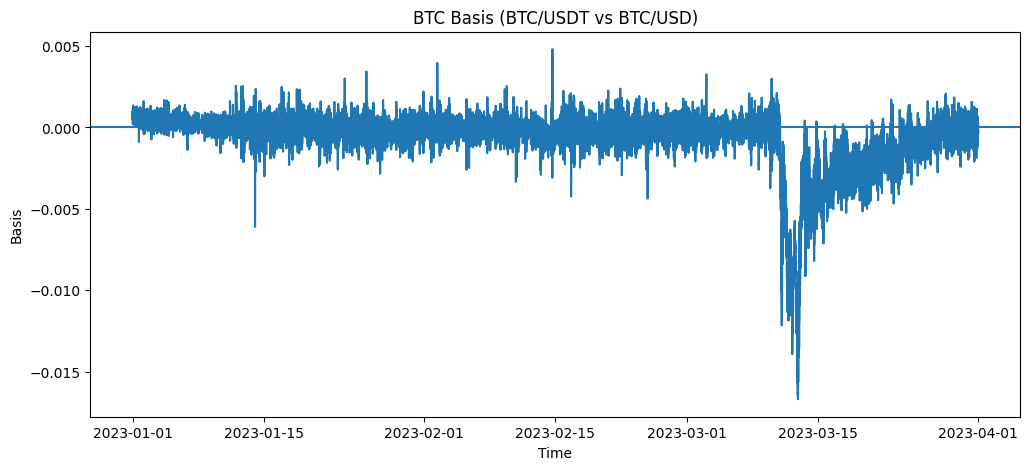

In [3]:
# =====================================
# 5. Figure 1: Basis Time Series
# =====================================
plt.figure(figsize=(12,5))
plt.plot(df['time'], df['basis'])
plt.axhline(0)
plt.title("BTC Basis (BTC/USDT vs BTC/USD)")
plt.xlabel("Time")
plt.ylabel("Basis")
plt.show()


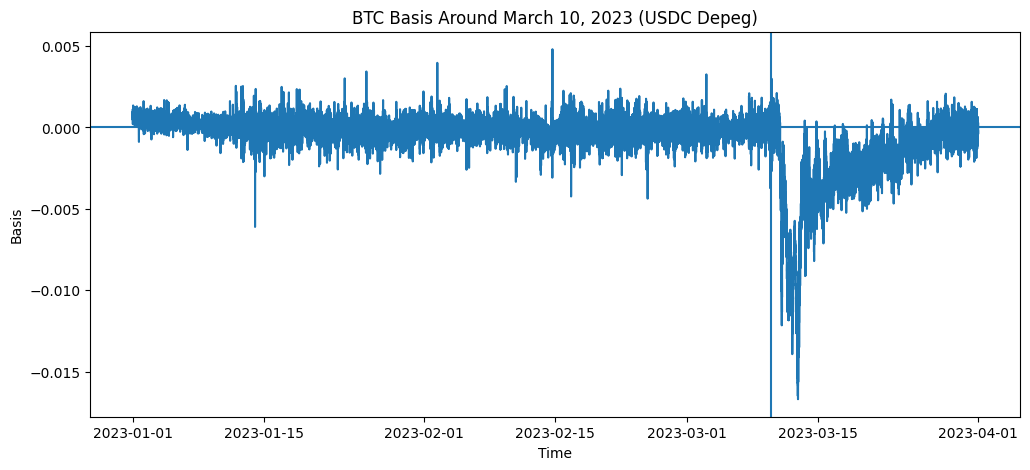

In [4]:
# =====================================
# Highlight March 10, 2023 (USDC depeg event)
# =====================================
event_date = pd.Timestamp("2023-03-10")

plt.figure(figsize=(12,5))
plt.plot(df['time'], df['basis'])
plt.axvline(event_date)
plt.axhline(0)
plt.title("BTC Basis Around March 10, 2023 (USDC Depeg)")
plt.xlabel("Time")
plt.ylabel("Basis")
plt.show()


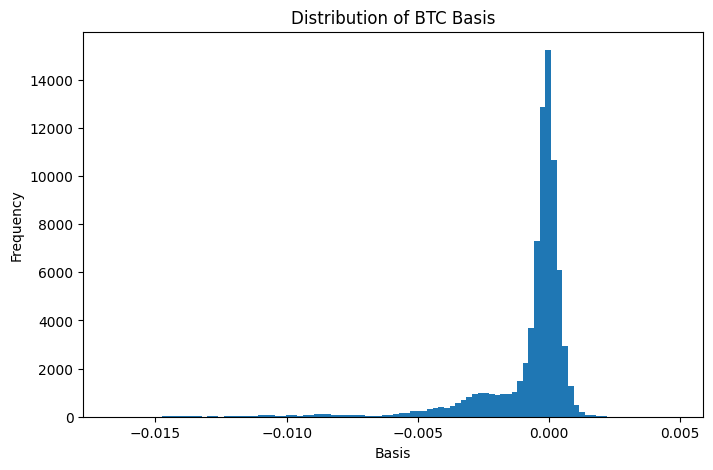

In [5]:
# =====================================
# 6. Figure 2: Histogram of Basis
# =====================================
plt.figure(figsize=(8,5))
plt.hist(df['basis'], bins=100)
plt.title("Distribution of BTC Basis")
plt.xlabel("Basis")
plt.ylabel("Frequency")
plt.show()


In [6]:
# =====================================
# 7. Compare volatility before and after March 10
# =====================================
before = df[df['time'] < '2023-03-10']['basis']
after = df[df['time'] >= '2023-03-10']['basis']

print("\n===== Volatility Comparison =====")
print("Std Before March 10:", before.std())
print("Std After March 10:", after.std())


===== Volatility Comparison =====
Std Before March 10: 0.00042886432842434153
Std After March 10: 0.002623447271674679


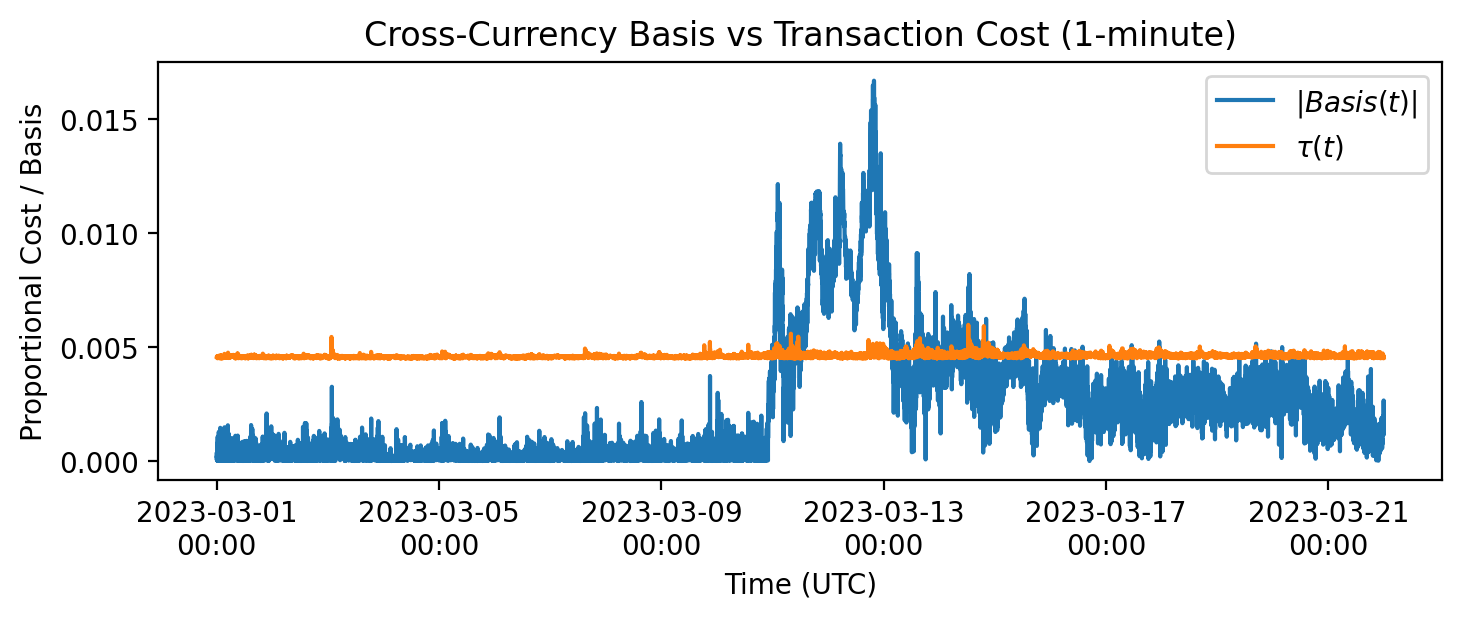

Saved: basis_vs_transaction_cost_clean_xaxis.png


In [7]:
# Generate the "Cross-Currency Basis vs Transaction Cost (1-minute)" graph
# using your uploaded CSVs:
# - Kraken_BTCUSD_1m_20230301_20230321.csv
# - Kraken_BTCUSDT_1m_20230301_20230321.csv
# - liquidity_bid_ask_spread_percent_1m.csv
#
# Output: basis_vs_transaction_cost_clean_xaxis.png

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- 1) Load data ----------
usd = pd.read_csv("Kraken_BTCUSD_1m_20230301_20230321.csv")
usdt = pd.read_csv("Kraken_BTCUSDT_1m_20230301_20230321.csv")
spread = pd.read_csv("new_liquidity_bid_ask_spread_percent_1m.csv")

# ---------- 2) Parse timestamps ----------
# Kraken files: unix seconds in "timestamp"
usd["dt"] = pd.to_datetime(usd["timestamp"], unit="s", utc=True)
usdt["dt"] = pd.to_datetime(usdt["timestamp"], unit="s", utc=True)

# CoinMetrics spread file: ISO time in "time"
spread["dt"] = pd.to_datetime(spread["time"], utc=True)

# ---------- 3) Merge BTCUSD and BTCUSDT prices ----------
# Use "close" as the price series (consistent with your current basis approach)
usd_px = usd[["dt", "close"]].rename(columns={"close": "p_usd"})
usdt_px = usdt[["dt", "close"]].rename(columns={"close": "p_usdt"})
px = pd.merge(usd_px, usdt_px, on="dt", how="inner")

# ---------- 4) Merge with 1-minute spreads ----------
# Columns in spread file are expected to include:
# "kraken-btc-usd-spot" and "kraken-btc-usdt-spot"
df = pd.merge(
    px,
    spread[["dt", "kraken-btc-usd-spot", "kraken-btc-usdt-spot"]],
    on="dt",
    how="inner",
).sort_values("dt")

# ---------- 5) Compute basis ----------
df["basis"] = (df["p_usdt"] - df["p_usd"]) / df["p_usd"]
df["abs_basis"] = df["basis"].abs()

# ---------- 6) Compute transaction cost tau(t) ----------
# fees as decimals
f_trade = 0.002   # 0.20%
f_conv  = 0.0005  # 0.05%

# CoinMetrics *_percent_* is in percent units -> convert to decimal proportion
df["spread_usd"]  = df["kraken-btc-usd-spot"] / 100.0
df["spread_usdt"] = df["kraken-btc-usdt-spot"] / 100.0

df["tau"] = 0.5 * df["spread_usd"] + 0.5 * df["spread_usdt"] + 2*f_trade + f_conv

# ---------- 7) Plot with cleaner x-axis ----------
plt.figure(figsize=(7.5, 3.2), dpi=200)

plt.plot(df["dt"], df["abs_basis"], label=r"$|Basis(t)|$")
plt.plot(df["dt"], df["tau"], label=r"$\tau(t)$")

ax = plt.gca()
# Show date on first line and time on second line
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xlabel("Time (UTC)")
plt.ylabel("Proportional Cost / Basis")
plt.title("Cross-Currency Basis vs Transaction Cost (1-minute)")
plt.legend()
plt.tight_layout()

plt.savefig("basis_vs_transaction_cost_clean_xaxis.png")
plt.show()
plt.close()
print("Saved: basis_vs_transaction_cost_clean_xaxis.png")

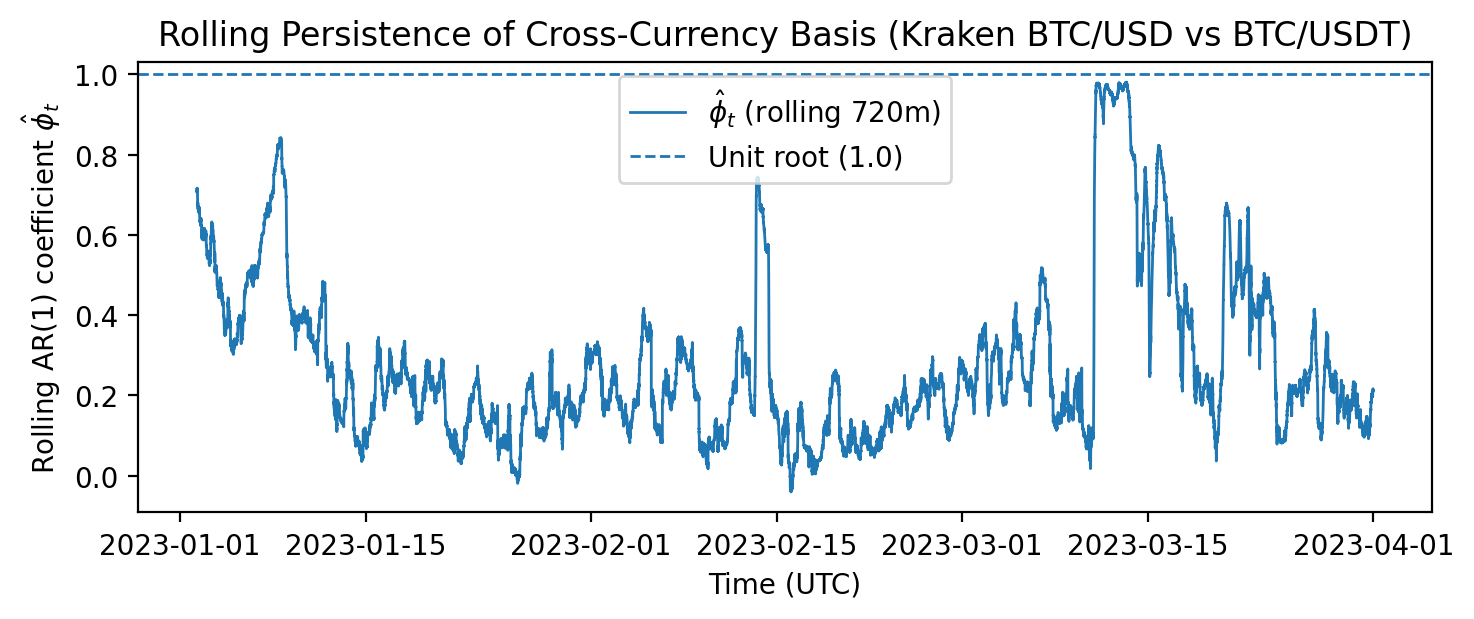

Saved: rolling_ar1_phi_kraken_basis_12h.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

WINDOW_MINUTES = 720  # 12 hours
OUT_PATH = "rolling_ar1_phi_kraken_basis_12h.png"

# ----------------------------
# 1) Load 1-minute price data
# ----------------------------
usd = pd.read_csv("Kraken_BTCUSD_1m_20230301_20230321.csv")
usdt = pd.read_csv("Kraken_BTCUSDT_1m_20230301_20230321.csv")

usd["dt"] = pd.to_datetime(usd["timestamp"], unit="s", utc=True)
usdt["dt"] = pd.to_datetime(usdt["timestamp"], unit="s", utc=True)

usd_px = usd[["dt", "close"]].rename(columns={"close": "p_usd"})
usdt_px = usdt[["dt", "close"]].rename(columns={"close": "p_usdt"})
df = pd.merge(usd_px, usdt_px, on="dt", how="inner").sort_values("dt")

# ----------------------------
# 2) Compute cross-currency basis
# Basis(t) = (P_USDT - P_USD) / P_USD
# ----------------------------
df["basis"] = (df["p_usdt"] - df["p_usd"]) / df["p_usd"]

# AR(1) pairs: y_t = basis_t, x_t = basis_{t-1}
df["x"] = df["basis"].shift(1)
df["y"] = df["basis"]
df = df.dropna(subset=["x", "y"]).reset_index(drop=True)

# ----------------------------
# 3) Rolling OLS slope with intercept (phi_hat)
# phi = Cov(x,y) / Var(x) computed within each rolling window
# ----------------------------
x = df["x"]
y = df["y"]
n = WINDOW_MINUTES

sum_x  = x.rolling(n).sum()
sum_y  = y.rolling(n).sum()
sum_xx = (x * x).rolling(n).sum()
sum_xy = (x * y).rolling(n).sum()

num = sum_xy - (sum_x * sum_y) / n
den = sum_xx - (sum_x * sum_x) / n

df["phi_hat"] = num / den

phi = df[["dt", "phi_hat"]].dropna()
phi = phi[np.isfinite(phi["phi_hat"])].copy()

# ----------------------------
# 4) Plot
# ----------------------------
plt.figure(figsize=(7.5, 3.2), dpi=200)
plt.plot(phi["dt"], phi["phi_hat"], linewidth=1,
         label=rf"$\hat{{\phi}}_t$ (rolling {WINDOW_MINUTES}m)")
plt.axhline(1.0, linestyle="--", linewidth=1, label="Unit root (1.0)")

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xlabel("Time (UTC)")
plt.ylabel(r"Rolling AR(1) coefficient $\hat{\phi}_t$")
plt.title("Rolling Persistence of Cross-Currency Basis (Kraken BTC/USD vs BTC/USDT)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PATH)
plt.show()
plt.close()

print(f"Saved: {OUT_PATH}")


BTC/USD  range: 2023-01-01 00:00:00+00:00 -> 2023-03-31 23:59:00+00:00 rows: 129298
BTC/USDT range: 2023-01-01 00:01:00+00:00 -> 2023-03-31 23:59:00+00:00 rows: 79372
Spreads   range: 2023-03-01 00:00:00+00:00 -> 2023-03-21 23:59:00+00:00 rows: 30240
Merged rows: 20416 | range: 2023-03-01 00:01:00+00:00 -> 2023-03-21 23:59:00+00:00
Mean basis: -0.002389 | Std basis:  0.002843
Mean tau:    0.004632
Violation rate P(|Basis| > tau): 14.6160%


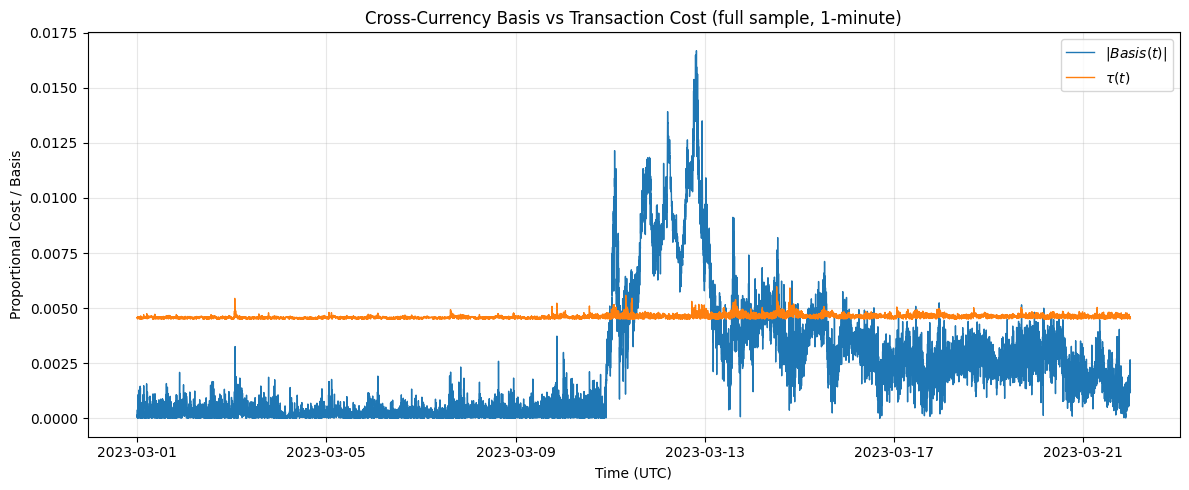

/var/folders/xt/g4dt2xmn47x1nq6hz8n9pvl80000gn/T/ipykernel_27519/1350125110.py:136: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily = tmp.groupby("date", as_index=False).apply(lambda g: (g["abs_basis"] > g["tau"]).mean())


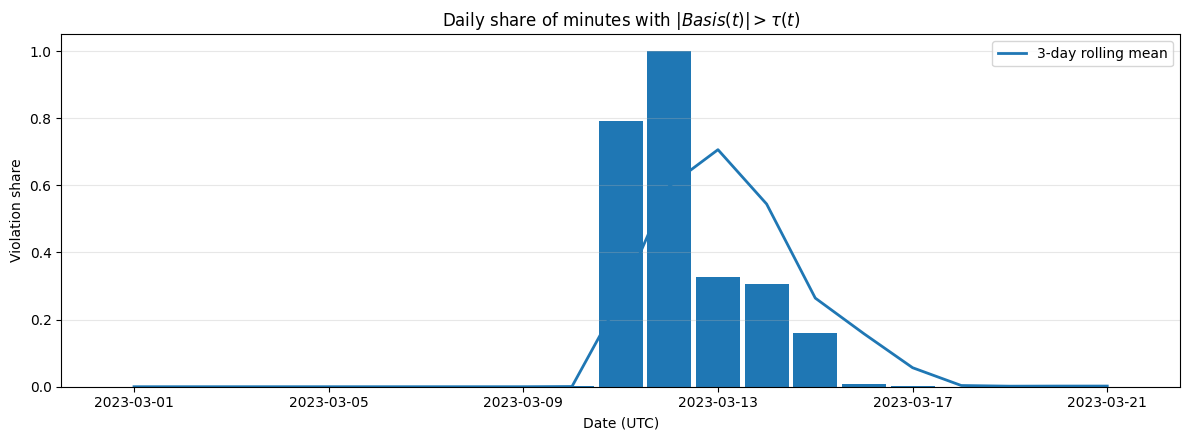

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Paths (edit if needed)
# =========================
BTCUSD_PATH  = "Kraken_BTCUSD_1m_20230301_20230321.csv"
BTCUSDT_PATH = "Kraken_BTCUSDT_1m_20230301_20230321.csv"
SPREAD_PATH  = "new_liquidity_bid_ask_spread_percent_1m.csv"

# =========================
# Parameters
# =========================
FEE_TRADE = 0.0020      # 0.20% taker fee
FEE_CONV  = 0.0005      # 0.05% conversion friction

# =========================
# Helpers
# =========================
def read_price_csv(path: str, price_col_candidates=("close", "price")) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Find price column
    price_col = None
    for c in price_col_candidates:
        if c in df.columns:
            price_col = c
            break
    if price_col is None:
        raise ValueError(f"[{path}] Cannot find a price column. Columns: {df.columns.tolist()}")

    if "timestamp" not in df.columns:
        raise ValueError(f"[{path}] Missing 'timestamp' column. Columns: {df.columns.tolist()}")

    out = df[["timestamp", price_col]].copy()
    out["time"] = pd.to_datetime(out["timestamp"], unit="s", utc=True).dt.floor("min")
    out = out.drop(columns=["timestamp"]).rename(columns={price_col: "price"})
    out = out.dropna(subset=["time", "price"]).drop_duplicates("time").sort_values("time")
    return out[["time", "price"]]

def read_spread_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if "time" not in df.columns:
        raise ValueError(f"[{path}] Missing 'time' column. Columns: {df.columns.tolist()}")

    # Your file columns are:
    # 'kraken-btc-usd-spot', 'kraken-btc-usdt-spot'
    needed = ["kraken-btc-usd-spot", "kraken-btc-usdt-spot"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(
            f"[{path}] Missing spread columns: {missing}. "
            f"Columns present: {df.columns.tolist()}"
        )

    out = df[["time"] + needed].copy()
    out["time"] = pd.to_datetime(out["time"], utc=True).dt.floor("min")

    out = out.rename(columns={
        "kraken-btc-usd-spot": "spread_usd_pct",
        "kraken-btc-usdt-spot": "spread_usdt_pct"
    })

    # Make numeric
    out["spread_usd_pct"]  = pd.to_numeric(out["spread_usd_pct"], errors="coerce")
    out["spread_usdt_pct"] = pd.to_numeric(out["spread_usdt_pct"], errors="coerce")

    out = out.dropna(subset=["time", "spread_usd_pct", "spread_usdt_pct"])
    out = out.drop_duplicates("time").sort_values("time")

    # IMPORTANT: This file is "spread_percent", i.e. percent units.
    # Convert percent -> decimal proportion (e.g., 0.02% becomes 0.0002)
    out["spread_usd"]  = out["spread_usd_pct"]  / 100.0
    out["spread_usdt"] = out["spread_usdt_pct"] / 100.0

    return out[["time", "spread_usd", "spread_usdt"]]

# =========================
# Load data
# =========================
usd  = read_price_csv(BTCUSD_PATH).rename(columns={"price": "p_usd"})
usdt = read_price_csv(BTCUSDT_PATH).rename(columns={"price": "p_usdt"})
spr  = read_spread_csv(SPREAD_PATH)

print("BTC/USD  range:", usd["time"].min(),  "->", usd["time"].max(),  "rows:", len(usd))
print("BTC/USDT range:", usdt["time"].min(), "->", usdt["time"].max(), "rows:", len(usdt))
print("Spreads   range:", spr["time"].min(),  "->", spr["time"].max(),  "rows:", len(spr))

# Inner join on common 1-minute timestamps
df = usd.merge(usdt, on="time", how="inner").merge(spr, on="time", how="inner")
df = df.sort_values("time").reset_index(drop=True)

if df.empty:
    raise RuntimeError(
        "Merged dataframe is empty. This means timestamps do not overlap after "
        "UTC conversion + minute flooring. Print the ranges above and confirm."
    )

print("Merged rows:", len(df), "| range:", df["time"].min(), "->", df["time"].max())

# =========================
# Compute Basis and tau
# =========================
df["basis"] = (df["p_usdt"] - df["p_usd"]) / df["p_usd"]
df["abs_basis"] = df["basis"].abs()

df["tau"] = 0.5 * df["spread_usd"] + 0.5 * df["spread_usdt"] + 2 * FEE_TRADE + FEE_CONV

viol_rate = (df["abs_basis"] > df["tau"]).mean()
print(f"Mean basis: {df['basis'].mean(): .6f} | Std basis: {df['basis'].std(): .6f}")
print(f"Mean tau:   {df['tau'].mean(): .6f}")
print(f"Violation rate P(|Basis| > tau): {viol_rate:.4%}")

# =========================
# Plot 1: Full sample |Basis| vs tau
# =========================
plt.figure(figsize=(12, 5))
plt.plot(df["time"], df["abs_basis"], label=r"$|Basis(t)|$", linewidth=1)
plt.plot(df["time"], df["tau"],      label=r"$\tau(t)$",     linewidth=1)
plt.title("Cross-Currency Basis vs Transaction Cost (full sample, 1-minute)")
plt.xlabel("Time (UTC)")
plt.ylabel("Proportional Cost / Basis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_basis_vs_tau_full.png", dpi=200)
plt.show()

# =========================
# Plot 2: Daily violation share (bars) + rolling mean (less “simple”)
# =========================
tmp = df.copy()
tmp["date"] = tmp["time"].dt.date
daily = tmp.groupby("date", as_index=False).apply(lambda g: (g["abs_basis"] > g["tau"]).mean())
daily = daily.rename(columns={None: "viol_share"})
daily["date"] = pd.to_datetime(daily["date"])
daily["viol_share_3d_ma"] = daily["viol_share"].rolling(3, min_periods=1).mean()

plt.figure(figsize=(12, 4.5))
plt.bar(daily["date"], daily["viol_share"], width=0.9)
plt.plot(daily["date"], daily["viol_share_3d_ma"], linewidth=2, label="3-day rolling mean")
plt.title(r"Daily share of minutes with $|Basis(t)| > \tau(t)$")
plt.xlabel("Date (UTC)")
plt.ylabel("Violation share")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_violation_share_daily.png", dpi=200)
plt.show()

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats.mstats import winsorize

# ---------- 1) Load data ----------
usd = pd.read_csv("Kraken_BTCUSD_1m_20230301_20230321.csv")
usdt = pd.read_csv("Kraken_BTCUSDT_1m_20230301_20230321.csv")
spread = pd.read_csv("new_liquidity_bid_ask_spread_percent_1m.csv")

# ---------- 2) Parse timestamps ----------
usd["dt"] = pd.to_datetime(usd["timestamp"], unit="s", utc=True)
usdt["dt"] = pd.to_datetime(usdt["timestamp"], unit="s", utc=True)
spread["dt"] = pd.to_datetime(spread["time"], utc=True)

# ---------- 3) Merge prices and volumes ----------
usd_px = usd[["dt", "close", "volume"]].rename(columns={"close": "p_usd", "volume": "vol_usd"})
usdt_px = usdt[["dt", "close", "volume"]].rename(columns={"close": "p_usdt", "volume": "vol_usdt"})
df = pd.merge(usd_px, usdt_px, on="dt", how="inner")

# ---------- 4) Merge spreads ----------
df = pd.merge(
    df,
    spread[["dt", "kraken-btc-usd-spot", "kraken-btc-usdt-spot"]],
    on="dt",
    how="inner"
).sort_values("dt")

# ---------- 5) Compute spreads ----------
df["spread_usd"]  = df["kraken-btc-usd-spot"] / 100.0
df["spread_usdt"] = df["kraken-btc-usdt-spot"] / 100.0
df["spread_avg"] = 0.5 * (df["spread_usd"] + df["spread_usdt"])

# ---------- 6) Compute transaction cost tau ----------
f_trade = 0.002   # 0.2%
f_conv  = 0.0005  # 0.05%
df["tau"] = 0.5*df["spread_usd"] + 0.5*df["spread_usdt"] + 2*f_trade + f_conv

# ---------- 7) Compute net basis ----------
df["basis"] = (df["p_usdt"] - df["p_usd"]) / df["p_usd"]
df["abs_basis"] = df["basis"].abs()
df["net_basis"] = df["abs_basis"] - df["tau"]
df["d_net_basis"] = df["net_basis"].diff()
df = df.dropna(subset=["d_net_basis"])

# ---------- Lag of net basis ----------
df["net_basis_lag1"] = df["d_net_basis"].shift(1)

# ---------- 8) Volatility ----------
df["ret"] = df["p_usd"].pct_change()

df["volatility"] = df["ret"].ewm(span=5).std()
df = df.dropna(subset=["volatility"])

# ---------- 9) Log volume ----------
df["volume"] = (df["vol_usd"] + df["vol_usdt"]) / 2
df["log_volume"] = np.log(df["volume"] + 1e-8)

# ---------- 10) Event dummy ----------
df["event_dummy"] = (df["dt"] >= "2023-03-10").astype(int)

df["spread_avg"] = winsorize(df["spread_avg"], limits=[0.01, 0.01]).astype(float)
df["volatility"] = winsorize(df["volatility"], limits=[0.01, 0.01]).astype(float)

from sklearn.preprocessing import StandardScaler
# ---------- 13) Prepare regression dataset ----------
reg_df = df[[
    "net_basis",
    "net_basis_lag1",
    "spread_avg",
    "volatility",
    "log_volume",
    "event_dummy"
]].dropna()

# standard
scale_cols = [
    "net_basis_lag1",
    "spread_avg",
    "volatility",
    "log_volume"
]

scaler = StandardScaler()
reg_df[scale_cols] = scaler.fit_transform(reg_df[scale_cols])

# square term
reg_df["spread_sq"] = reg_df["spread_avg"]**2

# ---------- 14) Regression ----------
X = reg_df[[
    "net_basis_lag1",
    "spread_avg",
    "spread_sq",
    "volatility", 
    "log_volume",
    "event_dummy"
]]

y = reg_df["net_basis"]

X = sm.add_constant(X)

model = sm.QuantReg(y, X).fit(q=0.5)

print(model.summary())

                         QuantReg Regression Results                          
Dep. Variable:              net_basis   Pseudo R-squared:               0.3780
Model:                       QuantReg   Bandwidth:                   0.0001259
Method:                 Least Squares   Sparsity:                     0.001149
Date:                Thu, 26 Feb 2026   No. Observations:                20413
Time:                        14:39:01   Df Residuals:                    20406
                                        Df Model:                            6
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0044   8.79e-06   -503.402      0.000      -0.004      -0.004
net_basis_lag1  1.479e-05   4.02e-06      3.680      0.000    6.91e-06    2.27e-05
spread_avg      4.301e-05   6.28e-06      6.847      0.000    3.07e-05    5.53e-05
spread_sq          0.0001   2.71